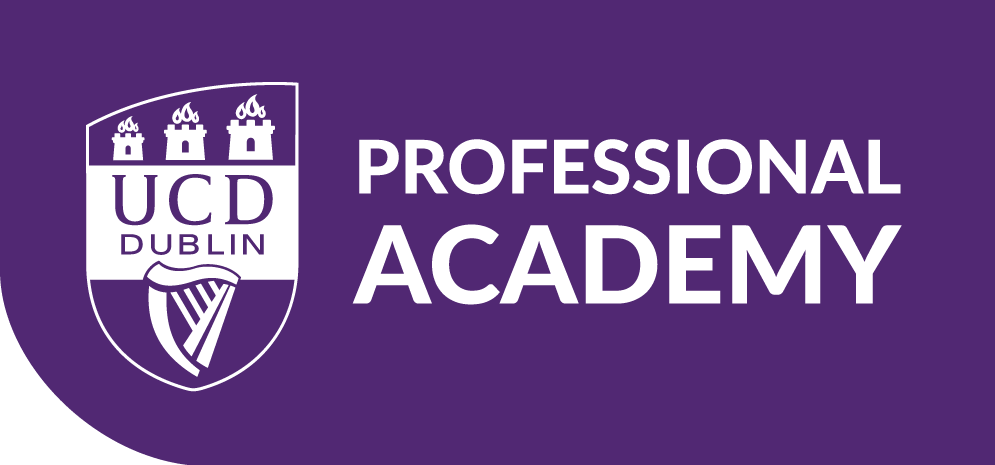
<h1 style="margin-top: -5px; margin-left: 40px; text-align: center; font-size: 3em;"><strong>Professional Certificate in Python Programming</strong></h1>

# Week 5 - Object Oriented Programming

## Our agenda:

1. Discuss last week's content and assessment
1. Introduction of Object Oriented Programming concepts
1. Instantiation
1. Class methods and constructors and the self keyword
1. Vectors and their norm as a second example
1. The repr and str methods
1. Emulating built-in types
1. Inheritance and method overriding
1. Multiple inheritance
1. Excercise Time

# How was last week?

# What's the deal with Object-Oriented Programming?

Until now, we learned about the basic data types, and the built-in data structures, as well as about functions working on them, as independent entities.

In addition, we mentioned that everything in Python is an object, and that methods are functions attached to objects (e.g. a string's `.lower()` method)

In today's lecture, we'll talk about creating our own custom data types, to combine data and behaviour.

In [ ]:
# Python uses "Class-based" objects, which means that to create a new kind of object, we need to define a class
# A class would represent a type of entity in the real world (or at least in our domain). Let's take a Person as an example
# To create a class, we use the Class keyword and the convention is to start a class name with an upper-case letter
# If we don't want to put anything special in our class, we can just use the no-op statement `pass`:

class Person:
    ## pass here just lets us create an empty container class
    pass


# we then call the class as if it were a function to create a new object of that class, this is officially called instantiation, with each object being an "instance" of the class
alice = Person()
bob = Person()

# we could then assign each object attributes that are unique to that instance:
alice.age = 34
bob.age = 29

## Add a new attribute to alice and bob you can pick


# each object's attributes are independent
## What happens when we change Alice's age? Why does this happen?
assert alice.age == 34

# we could attach as many attributes as we want to each object
alice.hair_colour = "blonde"
bob.hair_colour = "brown"

In [ ]:
# But in the class above, we haven't actually defined anything specific to a person, and every instance can be entirely different
# Instead, we usually want each class to have a structure specific to the entity it represents. Let's start by adding the `age` and `hair_color` attributes to the class itself

class Person:
    age = 18
    hair_colour = "brown"

# These become the default values for the attributes of each instance (also note that we don't need the `pass` anymore)
alice = Person()
print(f"{alice.age=}, {alice.hair_colour=}")

# Make a person bob what age is he?

In [ ]:
# Let's now set those values to the 'real' values for Alice:
alice.age = 34
alice.hair_colour = "blonde"

# The attributes assigned to an object override those on a class
print(f"{alice.age=}, {alice.hair_colour=}")

# Change bob too, we can't forget about him

In [ ]:
# But they don't change the class attributes, which will still be the defaults for future instances:
tom = Person()
print(f"{tom.age=}, {tom.hair_colour=}")

# Bob already has the default hair colour, such that we only need to override their age:
tom.age = 29
print(f"{tom.age=}, {tom.hair_colour=}")
print(tom.age)

In [ ]:
# So far we only used data, but we said that objects are about combining data and behaviour, so let's do that now by adding a method to our class:

class Person:
    age = 18
    hair_colour = "brown"

    def describe(self):  # Note the special parameter `self` that allows the method to refer to the object itself
        return f"Aged {self.age}, with {self.hair_colour} hair"


alice = Person()
alice.describe()

In [ ]:
alice.age = 34
alice.hair_colour = 'blonde'
alice.describe()

In [ ]:
# Objects are about combining the entity's data with all the relevant behaviour, so why are we still changing hair_colour manually?
# Let's add another method that changes the person object by dyeing their hair

class Person:
    age = 18
    hair_colour = "brown"

    def describe(self):  # Note the special parameter `self` that allows the method to refer to the object itself
        return f"Aged {self.age}, with {self.hair_colour} hair"
    
    def dye_hair(self, new_colour):
        print(f"Dyeing to {new_colour}")
        self.hair_colour = new_colour  # remember to use `self` whenever referring to the object


alice = Person()
print(alice.describe())

alice.dye_hair("blonde")
print(alice.describe())

# Adding a constructor
A constructor (aka initialiser) is a special method that is run whenever we create a new object.
In Python, all special methods have specific names that are always preceded and succeeded by a double underscore, and we usually refer to them as "dunder" (double underscore) methods.
These are methods on your classes that the Python interpreter might call on its own (it will never call any method named without dunder).

The constructor method in Python must be named `__init__`.

In [ ]:
# Let's now use a constructor to provide our Person's age and hair colour.
class Person:
    # Note that the __init__ method is by convention always placed at the top
    # By using parameters with default values, we no longer need to use class attributes
    def __init__(self, age=18, hair_colour="brown"):
        self.age = age
        self.hair_colour = hair_colour

    def describe(self):  # Note the special parameter `self` that allows the method to refer to the object itself
        return f"Aged {self.age}, with {self.hair_colour} hair"
    
    def dye_hair(self, new_colour):
        print(f"Dyeing to {new_colour}")
        self.hair_colour = new_colour  # remember to use `self` whenever referring to the object


alice = Person(34)
#Create a new person
print(alice.describe())

alice.dye_hair("blonde")
print(alice.describe())

# We can still assign values directly to object attributes
alice.age = 35
print(alice.describe())
# But we typically prefer to avoid it and we'll later see ways around this

# Add a new attribute to the contructor. Try create a person with and without that attribute. What's the difference? Why

In [ ]:
# Let's see what happens when try to just look at the alice object:
alice

In [ ]:
# We can do better then that ugly default, by creating a __repr__ method, which usually takes the same form as the constructor:
class Person:
    def __init__(self, age=18, hair_colour="brown"):
        self.age = age
        self.hair_colour = hair_colour

    def __repr__(self):
        return f"Person(age={self.age}, hair_colour='{self.hair_colour}')"
        
    def describe(self):
        return f"Aged {self.age}, with {self.hair_colour} hair"
    
    def dye_hair(self, new_colour):
        print(f"Dyeing to {new_colour}")
        self.hair_colour = new_colour


alice = Person(34)
alice

In [ ]:
# But usually we will want a nicer print-out than the representation, this is the purpose of the __str__ method
# We already have our describe method, so we could just rename that

class Person:
    def __init__(self, age=18, hair_colour="brown"):
        self.age = age
        self.hair_colour = hair_colour

    def __repr__(self):
        return f"Person(age={self.age}, hair_colour={self.hair_colour})"
        
    def __str__(self):
        return f"Aged {self.age}, with {self.hair_colour} hair"
    
    def dye_hair(self, new_colour):
        print(f"Dyeing to {new_colour}")
        self.hair_colour = new_colour


alice = Person(34)
print(alice)  # Now we don't need to call a method to get a nice description anymore

# Inheritance
Inheritance is a central property of object-oriented programming, allowing us to define "child" classes based on "parent" classes. In this manner, we can have the child class "inherit" methods from their parent, enabling effective reuse of code, and simplifying polymorphism.

In [ ]:
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height
    
    def get_perimeter(self):
        return 2 * (self.width + self.height) 
    
rect = Rectangle(10, 12)
rect

In [ ]:
import math                     #using 'math.pi' below in get_perimeter()
class Circle:
    def __init__(self, radius):
        self.radius = radius
  
    def get_perimeter(self):
        return 2 * math.pi * self.radius

circ = Circle(5)
circ

In [ ]:
from math import pi                             #can also import using 'from math import...'

class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def __str__(self):
        return f"A Rectangle with a perimeter of {self.get_perimeter():0.2f}"

    def get_perimeter(self):
        return 2 * (self.width + self.height)    


class Circle:
    def __init__(self, radius):
        self.radius = radius

    def __str__(self):
        return f"A Circle with a perimeter of {self.get_perimeter():0.2f}"
    
    def get_perimeter(self):
        return 2 * pi * self.radius         # just 'pi' this time


shapes = [Rectangle(10, 12), Circle(5)]

for shape in shapes:
    print(shape)

In [ ]:
# Let's add a __str__ method to both Rectangle and Circle, to describe the shape and its perimeter:
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def __repr__(self):
        return f"Rectangle(width={self.width}, height={self.height})"
    
    def __str__(self):
        return f"A Rectangle with a perimeter of {self.get_perimeter():0.2f}"
    
    def __mul__(self, factor):
        return Rectangle(self.width * factor, self.height * factor)
    
    def get_perimeter(self):
        return 2 * (self.width + self.height)


class Circle:
    def __init__(self, radius):
        self.radius = radius

    def __repr__(self):
        return f"Circle(radius={self.radius})"

    def __str__(self):
        return f"A Circle with a perimeter of {self.get_perimeter():0.2f}"

    def __mul__(self, factor):
        return Circle(self.radius * factor)
    
    def get_perimeter(self):
        return 2 * pi * self.radius


shapes = [Rectangle(10, 20), Circle(10), Circle(5)]

for shape in shapes:
    print(shape)

In [ ]:
#Experiment with this: put inside a classes method and print it to see what it does
#       self.__class__.__name__ 

This works, but seeing how these methods are almost identical, wouldn't it be nice if we could define the method just once?

In [ ]:
# Well, both Rectangle and Circle are shapes, so let's define a Shape class
class Shape:
    def __str__(self):
        class_name = self.__class__.__name__  # It's not the most elegant, but this gives us the class name
        return f"A {class_name} with a perimeter of {self.get_perimeter():0.2f}"


class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def __repr__(self):
        return f"Rectangle(width={self.width}, height={self.height})"
    
    def __mul__(self, factor):
        return Rectangle(self.width * factor, self.height * factor)
    
    def get_perimeter(self):
        return 2 * (self.width + self.height)

    
class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius

    def __repr__(self):
        return f"Circle(radius={self.radius})"

    def __mul__(self, factor):
        return Circle(self.radius * factor)
    
    def get_perimeter(self):
        return 2 * pi * self.radius
    
rect1 = Rectangle(10, 20)
print(rect1)

circle1 = Circle(10)
print(circle1)

In [ ]:
# Note that we can "override" an inherited method by implementing it in the child class

class Shape:
    #override this below
    def __str__(self):
        class_name = self.__class__.__name__  
        return f"A {class_name} with a perimeter of {self.get_perimeter():0.2f}"


class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius

    def __repr__(self):
        return f"Circle(radius={self.radius})"
    
    def __str__(self):                          #'override': by redefining a method with the same name, we override it
        return f"I am a pretty circle"

    def __mul__(self, factor):
        return Circle(self.radius * factor)
    
    def get_perimeter(self):
        return 2 * pi * self.radius
    

circle1 = Circle(10)
print(circle1)

In [ ]:
# Multiple inheritance - we can inherit from more than one class

class Mum:
    def mum_care(self):
        return "Providing mommy care"

    
class Dad:
    def dad_care(self):
        return "Providing daddy care"

    
class Child(Mum, Dad):
    pass


bobby = Child()
bobby.mum_care(), bobby.dad_care()

In [ ]:
# But it can be quite problematic, running the risk of different parents having methods with the same name

class Mum:
    def care(self):
        return "Providing mommy care"

    
class Dad:
    def care(self):
        return "Providing daddy care"

    
class Child(Mum, Dad):
    pass


bobby = Child()
bobby.care()  # The child will use the first parent that has the method, going from left to right

In [ ]:
# Because of this and other issues with inheritance, the general recommendation is to
# prefer composition (has-a) to inheritance (is-a) relationships between classes
# (unless there's a strong clear case for inheritance)

class Mum:
    def care(self):
        return "Providing mommy care"

    
class Dad:
    def care(self):
        return "Providing daddy care"

    
class Child:
    def __init__(self):
        self.mum = Mum()
        self.dad = Dad()


bobby = Child()
bobby.mum.care(), bobby.dad.care()

# Time for a Test

## 1. Fill the missing pieces of the `Calculator` class
Fill `____` pieces of the `Calculator` implemention in order to pass the assertions.

In [ ]:
class Calculator:
    def __init__(self, var1, ____):
        self.____ = var1
        self.____ = _____
    
    def calculate_power(self):
        return self.____ ** ____.____
    
    def calculate_sum(____, var3):
        return ____.____ + ____.____ + var3

In [ ]:
calc = Calculator(2, 3)
assert calc.calculate_power() == 8
assert calc.calculate_sum(4) == 9

## 2. Finalize `StringManipulator` class
Fill `____` pieces and create implementation for `stripped_title()`.

In [ ]:
class StringManipulator:
    """____"""
    
    category = ____
    
    def __init__(self, original):
        self.string = ____
        
    def reverse_words(self):
        words = self.string.____
        self.string = ' '.join(reversed(____))
        
    def make_title(self):
        # Create implementation for this
        
    def get_manipulated(____):
        return self._____
    
assert StringManipulator.__doc__ == 'Docstring of StringManipulator'
assert StringManipulator.category == 'Manipulator'

str_manip = StringManipulator('cOOL pyThON')

str_manip.reverse_words()
assert str_manip.get_manipulated() == 'pyThON cOOL'

str_manip.make_title()
assert str_manip.get_manipulated() == 'Python Cool'

In [ ]:
assert StringManipulator.__doc__ == 'Docstring of StringManipulator'
assert StringManipulator.category == 'Manipulator'

str_manip = StringManipulator('cOOL pyThON')

str_manip.reverse_words()
assert str_manip.get_manipulated() == 'pyThON cOOL'

str_manip.make_title()
assert str_manip.get_manipulated() == 'Python Cool'

## 3. Create `Dog` class
Create `Dog` class which has the following specification:
* Dogs consume their energy by barking and gain energy by sleeping
* A fresh `Dog` instance has 10 units of energy
* `Dog` has a method `sleep` which gives 2 units of energy
* `Dog` has a method `bark` which consumes 1 unit of energy

In [ ]:
# Fill this

In [ ]:
doge = Dog()
assert doge.energy == 10

doge.bark()
doge.bark()
doge.bark()
assert doge.energy == 7

doge.sleep()
assert doge.energy == 9

another_doge = Dog()
assert another_doge.energy == 10

## 4. modify the class above to incorporate:
1. A maximum limit on the energy being 10 (even if you sleep more, it stays at 10)
1. A minimum limit on the energy being 0, and if you try to bark at 0, the bark fails
1. A getter that returns the current energy value. We didn't really cover these so do some research.

In [ ]:
# Fill this

# 5. Data analyzer - This is a tough one
Implement `DataAnalyzer` class which has the following specification:
* `__init__` takes one argument which is a path to the file to be analyzed
* `total_samples` method returns the amount of the data samples in the file
* `average` method returns the average of the data samples in the file
* `median` method returns the median of the data samples in the file
* `max_value` method returns the maximum value of the data samples in the file
* `min_value` method returns the minimum value of the data samples in the file
* `create_report` method returns a report (string) of the file in the following format:

```
Report for <filename>
samples: x
average: x.xx
median: xx.xx
max: xx.xx
min: x.xx
```
 
Note that average, median, max, and min should be presented with two decimal places in the report.

The format of the input file is comma separated and the file contains only numeric values.

If there is no data in the input file (empty file), `NoData` exception should be raised. Note: `NoData` should be your custom exception.

In [ ]:
# Your implementation here


Let's check that it raises NoData with empty file.

In [ ]:
## 1. 

class Calculator:
    def __init__(self, var1, var2):
        self.var1 = var1
        self.var2 = var2
    
    def calculate_power(self):
        return self.var1 ** self.var2
    
    def calculate_sum(self, var3):
        return self.var1 + self.var2 + var3
    
calc = Calculator(2, 3)
assert calc.calculate_power() == 8
assert calc.calculate_sum(4) == 9

In [ ]:
## 2.

class StringManipulator:
    """Docstring of StringManipulator"""
    
    category = 'Manipulator'
    
    def __init__(self, original):
        self.string = original
        
    def reverse_words(self):
        words = self.string.split()  # Splitting the string into words
        self.string = ' '.join(reversed(words))  # Reversing the list of words and joining them back
    
    def make_title(self):
        self.string = self.string.title()  # Converts the string to title case
    
    def get_manipulated(self):
        return self.string  # Return the manipulated string
    
# Test cases
assert StringManipulator.__doc__ == 'Docstring of StringManipulator'
assert StringManipulator.category == 'Manipulator'

str_manip = StringManipulator('cOOL pyThON')

str_manip.reverse_words()
assert str_manip.get_manipulated() == 'pyThON cOOL'

str_manip.make_title()
assert str_manip.get_manipulated() == 'Python Cool'


In [ ]:
## 3. 

class Dog:
    def __init__(self):
        self.energy = 10  # A fresh dog starts with 10 units of energy
        
    def sleep(self):
        self.energy += 2  # Sleeping gives the dog 2 units of energy
        
    def bark(self):
        self.energy -= 1  # Barking consumes 1 unit of energy

doge = Dog()
assert doge.energy == 10

doge.bark()
doge.bark()
doge.bark()
assert doge.energy == 7

doge.sleep()
assert doge.energy == 9

another_doge = Dog()
assert another_doge.energy == 10


In [ ]:
## 4.

class Dog:
    def __init__(self):
        self.energy = 10  # Private attribute, energy starts at 10
        
    def sleep(self):
        if self.energy < 10:  # Only allow sleeping if energy is less than the max limit
            self.energy += 2
            if self.energy > 10:
                self.energy = 10  # Ensure energy does not exceed 10
                
    def bark(self):
        if self.energy > 0:  # Bark only if energy is greater than 0
            self.energy -= 1
        else:
            print("The dog is too tired to bark.")
    
    def get_energy(self):
        return self.energy  # Returns the amount of energy left


In [ ]:
## 5.

import statistics

# Custom Exception for NoData
class NoData(Exception):
    pass

class DataAnalyzer:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = self._read_data_from_file()
    
    def _read_data_from_file(self):
        # Read the file and return the data as a list of floats
        try:
            with open(self.file_path, 'r') as file:
                lines = file.readlines()
                # Assuming the data is on a single line and separated by commas
                data = [float(value) for value in lines[0].split(',') if value.strip()]
                if not data:  # If there is no data
                    raise NoData("The file is empty or contains no valid data.")
                return data
        except FileNotFoundError:
            raise FileNotFoundError(f"The file at {self.file_path} was not found.")
        except NoData as e:
            raise e
    
    def total_samples(self):
        return len(self.data)  # Number of samples in the file
    
    def average(self):
        return round(sum(self.data) / len(self.data), 2)  # Average value of the samples
    
    def median(self):
        return round(statistics.median(self.data), 2)  # Median value of the samples
    
    def max_value(self):
        return round(max(self.data), 2)  # Maximum value of the samples
    
    def min_value(self):
        return round(min(self.data), 2)  # Minimum value of the samples
    
    def create_report(self):
        # Creating a report in the specified format
        report = f"Report for {self.file_path}\n"
        report += f"samples: {self.total_samples()}\n"
        report += f"average: {self.average()}\n"
        report += f"median: {self.median()}\n"
        report += f"max: {self.max_value()}\n"
        report += f"min: {self.min_value()}\n"
        return report

# Example usage:
try:
    # Assuming 'data.txt' contains comma-separated values
    analyzer = DataAnalyzer('data.txt')
    print(analyzer.create_report())
except NoData as e:
    print(e)
except Exception as e:
    print(e)
